# Credit Default Prediction — LendingClub Accepted Loans

Data pulled live from PostgreSQL (`finsight.loans`) via `src/db_connect.py`. Feature engineering, model
training, and threshold selection live in `src/credit_risk_model.py`; this notebook orchestrates the
pipeline, evaluates Logistic Regression vs XGBoost, and explains predictions with SHAP.

**Target population**: closed loans only (Fully Paid / Charged Off / Default). Loans that are still
Current, Late, or In Grace Period have no final outcome yet — including them would mean training on
loans we can't actually label as good or bad.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

from db_connect import get_engine
from eda_utils import SEQUENTIAL_BLUE, sequential_shades
import credit_risk_model as crm

%matplotlib inline
pd.set_option("display.max_columns", 50)
engine = get_engine()

C:\Users\Nirvana Das\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Target Definition & Population

In [2]:
status_counts = pd.read_sql(
    "SELECT loan_status, COUNT(*) AS n FROM finsight.loans GROUP BY loan_status ORDER BY n DESC", engine
)
display(status_counts)

closed_n = status_counts.loc[status_counts["loan_status"].isin(crm.CLOSED_LOAN_STATUSES), "n"].sum()
default_n = status_counts.loc[status_counts["loan_status"].isin(crm.DEFAULT_STATUSES), "n"].sum()
total_n = status_counts["n"].sum()
print(f"Total loans: {total_n:,}")
print(f"Closed loans (modeling population): {closed_n:,} ({100*closed_n/total_n:.1f}% of all loans)")
print(f"Default rate within closed loans: {100*default_n/closed_n:.2f}%")

,loan_status,n
0,Fully Paid,1078739
1,Current,878317
2,Charged Off,269320
3,Late (31-120 days),21467
4,In Grace Period,8436
5,Late (16-30 days),4349
6,Default,40


Total loans: 2,260,668
Closed loans (modeling population): 1,348,099 (59.6% of all loans)
Default rate within closed loans: 19.98%


## Leakage Check: grade / sub_grade / interest_rate / installment

`grade` and `sub_grade` are LendingClub's own risk assessment, assigned using essentially the same
underlying signals (FICO, DTI, income, credit history) this model is trying to learn from raw
application data. `interest_rate` is priced directly off `sub_grade` (each sub-grade maps to a narrow
rate band), and `installment` is a deterministic function of `loan_amount`, `term_months`, and
`interest_rate` — so keeping `installment` would smuggle `interest_rate` back in even after dropping
`interest_rate` itself.

Before deciding, quantify how tight these relationships actually are.

In [3]:
subgrade_stats = pd.read_sql("""
    SELECT sub_grade, COUNT(*) AS n,
           MIN(interest_rate) AS min_rate, MAX(interest_rate) AS max_rate,
           ROUND((MAX(interest_rate) - MIN(interest_rate))::numeric, 2) AS rate_spread
    FROM finsight.loans GROUP BY sub_grade ORDER BY sub_grade;
""", engine)
display(subgrade_stats)

portfolio_range = pd.read_sql("SELECT MIN(interest_rate) mn, MAX(interest_rate) mx FROM finsight.loans", engine).iloc[0]
avg_spread = subgrade_stats["rate_spread"].mean()
print(f"Portfolio-wide interest_rate range: {portfolio_range['mn']}% - {portfolio_range['mx']}% "
      f"({portfolio_range['mx']-portfolio_range['mn']:.2f} points)")
print(f"Average WITHIN-sub_grade interest_rate spread: {avg_spread:.2f} points "
      f"({100*avg_spread/(portfolio_range['mx']-portfolio_range['mn']):.1f}% of the full portfolio range)")

grade_sample = pd.read_sql("SELECT grade, interest_rate FROM finsight.loans TABLESAMPLE SYSTEM (2)", engine)
grade_map = {g: i for i, g in enumerate("ABCDEFG", start=1)}
grade_sample["grade_ordinal"] = grade_sample["grade"].map(grade_map)
grade_rate_corr = grade_sample[["grade_ordinal", "interest_rate"]].corr().iloc[0, 1]
print(f"Correlation between grade (ordinal A=1..G=7) and interest_rate: {grade_rate_corr:.3f}")

,sub_grade,n,min_rate,max_rate,rate_spread
0,A1,86790,5.31,7.37,2.06
1,A2,69562,5.79,7.68,1.89
2,A3,73184,6.00,8.00,2.00
3,A4,95874,6.00,9.32,3.32
4,A5,107617,6.00,9.63,3.63
5,B1,125341,6.00,11.49,5.49
6,B2,126621,6.00,11.48,5.48
7,B3,131514,6.00,12.12,6.12
8,B4,139793,6.00,13.11,7.11
9,B5,140288,6.00,14.09,8.09


Portfolio-wide interest_rate range: 5.31% - 30.99% (25.68 points)
Average WITHIN-sub_grade interest_rate spread: 14.44 points (56.2% of the full portfolio range)
Correlation between grade (ordinal A=1..G=7) and interest_rate: 0.954


### Decision: exclude `grade`, `sub_grade`, `interest_rate`, and `installment`

The correlation is the clean piece of evidence: grade (ordinal A=1..G=7) correlates with
interest_rate at r=0.954 (R^2 ~ 0.91) - grade alone explains about 91% of interest_rate's variance.
`sub_grade` narrows that further, since it's the actual pricing key.

The raw within-sub_grade spread number (14.44 points, 56.2% of the portfolio range) looks less clean
at first glance, but that's a vintage artifact, not evidence against leakage: these loans were issued
across 2007-2018, and LendingClub's own rate table drifted over that decade on top of the sub_grade
effect (e.g. sub_grade A1 ranges 5.31%-7.37%, a 2.06-point spread when you *do* hold time roughly
constant within a sub_grade's early vs late issuances - it's the multi-year drift across the full
sample that widens the naive min/max spread, not sub_grade failing to pin down price at a point in time).

Either way, the conclusion holds: an "underwriting" model is meant to independently assess risk from
raw application data. A model that gets to see LendingClub's own risk-pricing decision
(grade/sub_grade/interest_rate) or a near-perfect proxy for it (installment, a deterministic function
of loan_amount/term_months/interest_rate) would mostly be learning to decode that decision rather than
doing independent risk assessment - and its apparent accuracy would be inflated in a way that wouldn't
hold up if you actually had to price a brand new loan application. All four columns are excluded from
the feature set below (see `credit_risk_model.LEAKAGE_FEATURES`). This decision is re-confirmed
empirically near the end of the notebook by retraining with `grade` included and comparing AUC-ROC.

## Feature Engineering

In [4]:
# Raw DB columns needed: the numeric/categorical features used as-is, plus the raw
# inputs to engineer_features() (dti, fico_range_low, revol_util -> dti_bucket,
# fico_band, credit_utilization_ratio), plus loan_status (target) and the leakage
# columns (grade/sub_grade/interest_rate/installment) for the checks above/below.
RAW_PULL_COLS = sorted(set(
    ["loan_id", "loan_amount", "term_months", "annual_income", "dti", "delinq_2yrs",
     "open_accounts", "total_accounts", "revol_util", "fico_range_low",
     "employment_length", "home_ownership", "verification_status", "purpose",
     "loan_status", "grade", "sub_grade", "interest_rate", "installment"]
))

# Ordering by MD5(loan_id) rather than RANDOM() makes this a fixed, reproducible 300K-row
# sample - re-running the notebook always pulls the same rows instead of silently drifting
# the reported metrics on every execution.
raw_df = pd.read_sql(
    f"SELECT {', '.join(RAW_PULL_COLS)} FROM finsight.loans "
    f"WHERE loan_status IN {crm.CLOSED_LOAN_STATUSES} ORDER BY MD5(loan_id::text) LIMIT 300000",
    engine,
)
print(f"Pulled {len(raw_df):,} closed loans (random sample of the {closed_n:,}-loan closed population)")

model_df = crm.engineer_features(raw_df)
model_df = crm.make_target(model_df)
print(f"Post feature-engineering: {len(model_df):,} rows, default rate {100*model_df['default'].mean():.2f}%")

display(model_df["dti_bucket"].value_counts().sort_index())
display(model_df["fico_band"].value_counts().sort_index())

Pulled 300,000 closed loans (random sample of the 1,348,099-loan closed population)


Post feature-engineering: 300,000 rows, default rate 20.05%


dti_bucket
0-10      54701
10-20    125453
20-30     91270
30-40     27075
40+        1501
Name: count, dtype: int64

fico_band
Subprime (under 660)       111
Near-Prime (660-719)    237942
Prime (720+)             61947
Name: count, dtype: int64

## Train/Test Split

In [5]:
train_df, test_df = train_test_split(
    model_df, test_size=0.2, stratify=model_df["default"], random_state=42
)
print(f"Train: {len(train_df):,} rows ({100*train_df['default'].mean():.2f}% default)")
print(f"Test:  {len(test_df):,} rows ({100*test_df['default'].mean():.2f}% default)")

X_train_raw = crm.build_feature_matrix(train_df)
X_test_raw = crm.build_feature_matrix(test_df)
X_test_raw = crm.align_columns(X_test_raw, X_train_raw.columns)

X_train, X_test, scaler = crm.scale_numeric(X_train_raw, X_test_raw)
y_train, y_test = train_df["default"], test_df["default"]
print(f"Feature matrix: {X_train.shape[1]} columns after one-hot encoding")
print(list(X_train.columns))

Train: 240,000 rows (20.05% default)
Test:  60,000 rows (20.05% default)


Feature matrix: 45 columns after one-hot encoding
['loan_amount', 'term_months', 'annual_income', 'dti', 'delinq_2yrs', 'open_accounts', 'total_accounts', 'credit_utilization_ratio', 'dti_bucket_10-20', 'dti_bucket_20-30', 'dti_bucket_30-40', 'dti_bucket_40+', 'fico_band_Near-Prime (660-719)', 'fico_band_Prime (720+)', 'employment_length_10+ years', 'employment_length_2 years', 'employment_length_3 years', 'employment_length_4 years', 'employment_length_5 years', 'employment_length_6 years', 'employment_length_7 years', 'employment_length_8 years', 'employment_length_9 years', 'employment_length_under 1 year', 'employment_length_Unknown', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical

## Baseline: Logistic Regression

In [6]:
lr_model = crm.train_logistic_regression(X_train, y_train)
lr_proba = lr_model.predict_proba(X_test)[:, 1]
lr_metrics_50 = crm.evaluate_at_threshold(y_test, lr_proba, threshold=0.5)

print(f"Logistic Regression @ threshold=0.5")
print(f"  AUC-ROC:   {lr_metrics_50['auc_roc']:.4f}")
print(f"  Precision: {lr_metrics_50['precision']:.4f}")
print(f"  Recall:    {lr_metrics_50['recall']:.4f}")
print(f"  F1:        {lr_metrics_50['f1']:.4f}")
print(f"  Confusion matrix: {lr_metrics_50['confusion_matrix']}")

Logistic Regression @ threshold=0.5
  AUC-ROC:   0.6821
  Precision: 0.5517
  Recall:    0.0346
  F1:        0.0651
  Confusion matrix: {'tn': 47633, 'fp': 338, 'fn': 11613, 'tp': 416}


## XGBoost

In [7]:
xgb_model = crm.train_xgboost(X_train, y_train)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_metrics_50 = crm.evaluate_at_threshold(y_test, xgb_proba, threshold=0.5)

print(f"XGBoost @ threshold=0.5")
print(f"  AUC-ROC:   {xgb_metrics_50['auc_roc']:.4f}")
print(f"  Precision: {xgb_metrics_50['precision']:.4f}")
print(f"  Recall:    {xgb_metrics_50['recall']:.4f}")
print(f"  F1:        {xgb_metrics_50['f1']:.4f}")
print(f"  Confusion matrix: {xgb_metrics_50['confusion_matrix']}")

XGBoost @ threshold=0.5
  AUC-ROC:   0.6878
  Precision: 0.5395
  Recall:    0.0482
  F1:        0.0885
  Confusion matrix: {'tn': 47476, 'fp': 495, 'fn': 11449, 'tp': 580}


## Model Comparison — ROC Curves & Confusion Matrices

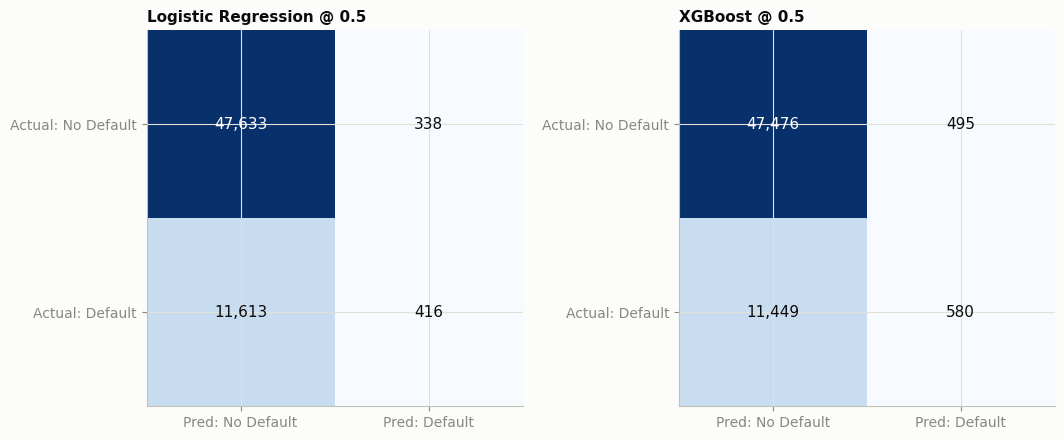

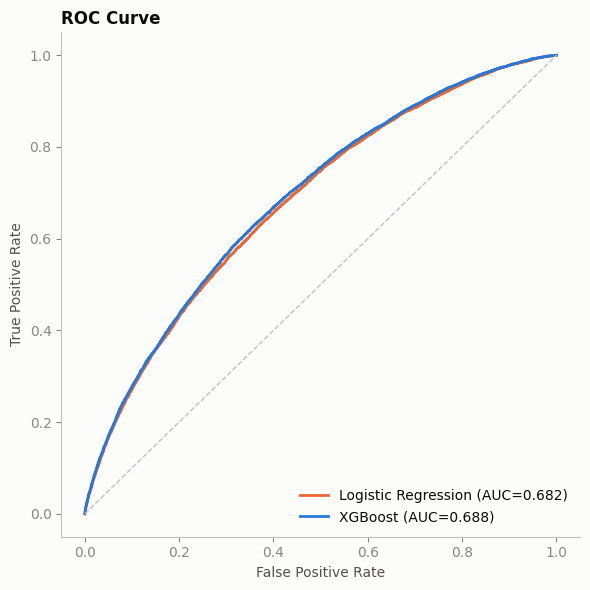

In [8]:
def plot_confusion(ax, cm_dict, title):
    cm = np.array([[cm_dict["tn"], cm_dict["fp"]], [cm_dict["fn"], cm_dict["tp"]]])
    im = ax.imshow(cm, cmap="Blues")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, f"{v:,}", ha="center", va="center",
                color="white" if v > cm.max() / 2 else "#0b0b0b", fontsize=11)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred: No Default", "Pred: Default"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual: No Default", "Actual: Default"])
    ax.set_title(title, loc="left", fontsize=11, fontweight="bold")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_confusion(axes[0], lr_metrics_50["confusion_matrix"], "Logistic Regression @ 0.5")
plot_confusion(axes[1], xgb_metrics_50["confusion_matrix"], "XGBoost @ 0.5")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
for proba, label, color in [(lr_proba, "Logistic Regression", "#eb6834"), (xgb_proba, "XGBoost", SEQUENTIAL_BLUE)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})", color=color, linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="#c3c2b7", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve", loc="left", fontsize=12, fontweight="bold")
ax.legend(loc="lower right", frameon=False)
ax.grid(visible=False)
fig.tight_layout()
plt.show()

## Precision-Recall Tradeoff & Threshold Selection

Using XGBoost (the stronger model) going forward. Business framing: a false negative (predicted safe,
actually defaults) costs the lender the unpaid principal; a false positive (predicted risky, actually
would have paid) only costs a marginally-qualified applicant a rejection. That asymmetry means recall
on the default class should be weighted well above precision - not a reason to optimize recall alone,
though: a threshold nobody can actually staff a review queue against isn't useful regardless of how
good it looks on paper. Both angles are shown below: the pure metric-optimal point first (as a
reference for "how far could recall theoretically go"), then a business tradeoff table calibrated to
review-queue capacity, which is the one to actually pick from.

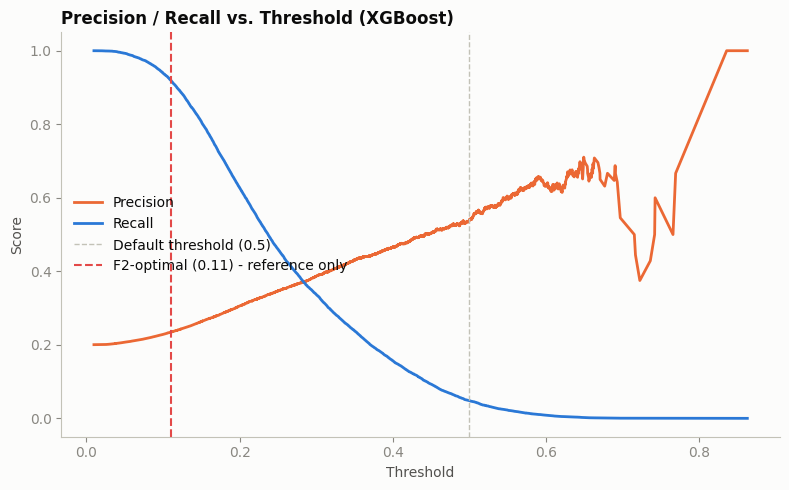

F2-optimal threshold: 0.110
  Precision: 0.2348  |  Recall: 0.9194  |  F1: 0.3741
  Flags 47,098 of 60,000 loans (78.5% of the portfolio) as risky
  NOT directly deployable as a review-queue cutoff at that flag rate - see the tradeoff table below.


In [9]:
pr_curve = crm.precision_recall_by_threshold(y_test, xgb_proba)

f2_threshold = crm.select_recall_favoring_threshold(y_test, xgb_proba, beta=2.0)
f2_metrics = crm.evaluate_at_threshold(y_test, xgb_proba, threshold=f2_threshold)
f2_flagged = f2_metrics["confusion_matrix"]["tp"] + f2_metrics["confusion_matrix"]["fp"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pr_curve["threshold"], pr_curve["precision"], label="Precision", color="#eb6834", linewidth=2)
ax.plot(pr_curve["threshold"], pr_curve["recall"], label="Recall", color=SEQUENTIAL_BLUE, linewidth=2)
ax.axvline(0.5, color="#c3c2b7", linestyle="--", linewidth=1, label="Default threshold (0.5)")
ax.axvline(f2_threshold, color="#e34948", linestyle="--", linewidth=1.5,
           label=f"F2-optimal ({f2_threshold:.2f}) - reference only")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall vs. Threshold (XGBoost)", loc="left", fontsize=12, fontweight="bold")
ax.legend(loc="center left", frameon=False)
ax.grid(visible=False)
fig.tight_layout()
plt.show()

print(f"F2-optimal threshold: {f2_threshold:.3f}")
print(f"  Precision: {f2_metrics['precision']:.4f}  |  Recall: {f2_metrics['recall']:.4f}  |  F1: {f2_metrics['f1']:.4f}")
print(f"  Flags {f2_flagged:,} of {len(y_test):,} loans ({100*f2_flagged/len(y_test):.1f}% of the portfolio) as risky")
print(f"  NOT directly deployable as a review-queue cutoff at that flag rate - see the tradeoff table below.")

### Business Tradeoff: Review-Queue Capacity Thresholds

A pure F2-optimal cutoff isn't a real option if it flags most of the portfolio - nobody can staff a
review queue against 78% of applicants. The more useful question is the reverse: **for a review queue
that can actually handle ~15% / ~25% / ~35% of loan volume, what recall does that buy, and how many
defaulters does it actually catch?** `crm.threshold_tradeoff_table()` calibrates the threshold to each
target flagged-rate directly (via the quantile of predicted probability), rather than optimizing a
metric and hoping the resulting flag rate happens to be practical.

,target_flagged_rate,threshold,actual_flagged_rate,flagged_count,precision,recall,f1,defaults_caught,defaults_missed
0,0.15,0.3169,0.15,9000,0.4003,0.2995,0.3427,3603,8426
1,0.25,0.2575,0.25,15000,0.3526,0.4397,0.3914,5289,6740
2,0.35,0.2189,0.35,21000,0.3219,0.5619,0.4093,6759,5270


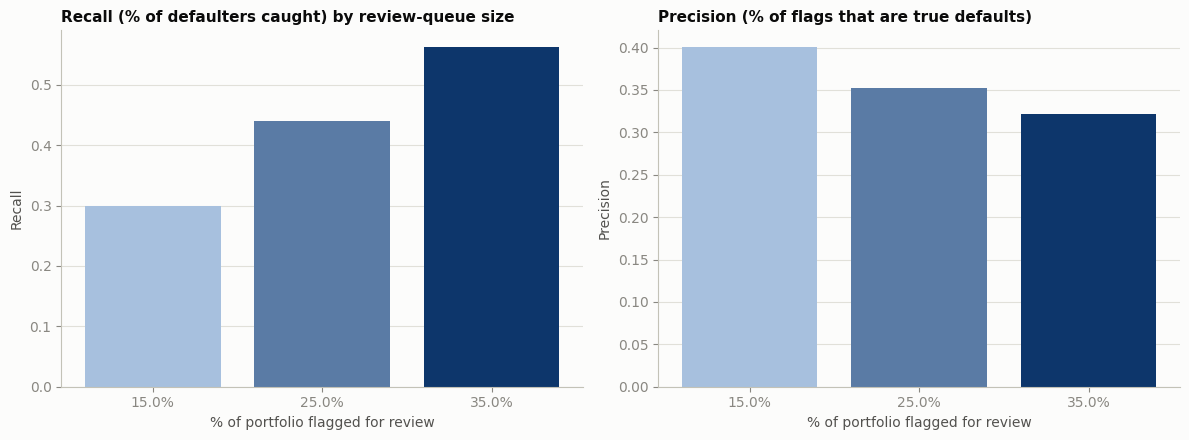

Flag ~15% of portfolio (threshold=0.317, actual flag rate=15.0%, 9,000.0 loans): catches 3,603.0 of 12,029.0 defaulters (recall=0.300), precision=0.400
Flag ~25% of portfolio (threshold=0.258, actual flag rate=25.0%, 15,000.0 loans): catches 5,289.0 of 12,029.0 defaulters (recall=0.440), precision=0.353
Flag ~35% of portfolio (threshold=0.219, actual flag rate=35.0%, 21,000.0 loans): catches 6,759.0 of 12,029.0 defaulters (recall=0.562), precision=0.322


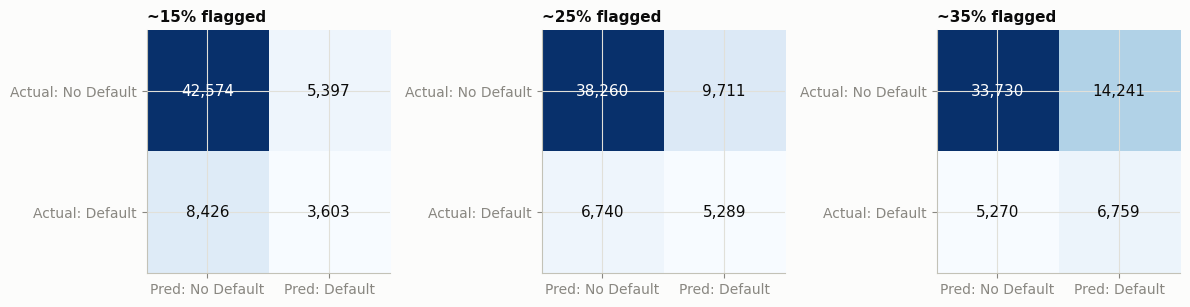

In [10]:
tradeoff = crm.threshold_tradeoff_table(y_test, xgb_proba, flagged_rates=[0.15, 0.25, 0.35])
display(tradeoff.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = tradeoff["actual_flagged_rate"] * 100
colors = sequential_shades(len(tradeoff))

axes[0].bar(x.round(1).astype(str) + "%", tradeoff["recall"], color=colors)
axes[0].set_title("Recall (% of defaulters caught) by review-queue size", loc="left", fontsize=11, fontweight="bold")
axes[0].set_xlabel("% of portfolio flagged for review")
axes[0].set_ylabel("Recall")
axes[0].grid(axis="x", visible=False)

axes[1].bar(x.round(1).astype(str) + "%", tradeoff["precision"], color=colors)
axes[1].set_title("Precision (% of flags that are true defaults)", loc="left", fontsize=11, fontweight="bold")
axes[1].set_xlabel("% of portfolio flagged for review")
axes[1].set_ylabel("Precision")
axes[1].grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

for _, row in tradeoff.iterrows():
    print(f"Flag ~{row['target_flagged_rate']*100:.0f}% of portfolio (threshold={row['threshold']:.3f}, "
          f"actual flag rate={row['actual_flagged_rate']*100:.1f}%, {row['flagged_count']:,} loans): "
          f"catches {row['defaults_caught']:,} of {row['defaults_caught']+row['defaults_missed']:,} defaulters "
          f"(recall={row['recall']:.3f}), precision={row['precision']:.3f}")

fig, axes = plt.subplots(1, len(tradeoff), figsize=(4 * len(tradeoff), 4))
for ax, (_, row) in zip(axes, tradeoff.iterrows()):
    metrics_i = crm.evaluate_at_threshold(y_test, xgb_proba, threshold=row["threshold"])
    plot_confusion(ax, metrics_i["confusion_matrix"], f"~{row['target_flagged_rate']*100:.0f}% flagged")
fig.tight_layout()
plt.show()

**How to read this table**: there's no single "correct" row - it's a genuine business tradeoff between
review-queue capacity and how many defaulters slip through uncaught, and the right pick depends on
capacity the underwriting/collections team actually has, not on a single optimized metric. As a rough
guide: the ~15% row is the cheapest to staff but catches the fewest defaulters; the ~35% row catches
meaningfully more defaulters per the recall figures above but roughly doubles the review workload and
almost certainly the false-positive count relative to ~15%; ~25% sits in between. The F2-optimal
threshold above (flagging ~78% of the portfolio) remains useful only as the theoretical upper bound on
recall - it's what "catch nearly everything, ignore review capacity" looks like, not a candidate cutoff.

## SHAP Feature Importance (XGBoost)

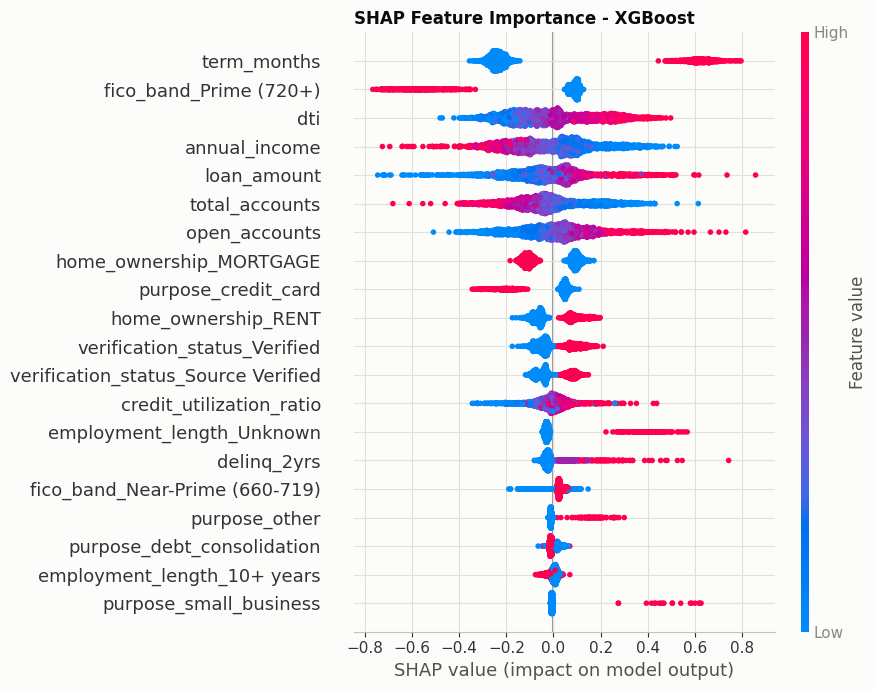

Top 8 features by mean |SHAP value|:
term_months                0.3329
fico_band_Prime (720+)     0.1825
dti                        0.1469
annual_income              0.1465
loan_amount                0.1313
total_accounts             0.1263
open_accounts              0.1255
home_ownership_MORTGAGE    0.1026


In [11]:
shap_sample = X_test.sample(n=2000, random_state=42)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(shap_sample)

shap.summary_plot(shap_values, shap_sample, show=False, plot_size=(9, 7))
plt.title("SHAP Feature Importance - XGBoost", loc="left", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=shap_sample.columns).sort_values(ascending=False)
print("Top 8 features by mean |SHAP value|:")
print(mean_abs_shap.head(8).round(4).to_string())

## Empirical Leakage Confirmation

Retrain XGBoost with `grade` added back in (ordinal-encoded A=1..G=7) on the identical train/test split,
and compare AUC-ROC to the leakage-free model above. If grade meaningfully inflates AUC and dominates
SHAP importance, that's direct empirical confirmation the earlier exclusion decision was correct — not
just a theoretical concern.

In [12]:
grade_map = {g: i for i, g in enumerate("ABCDEFG", start=1)}
X_train_leaky = X_train.copy()
X_test_leaky = X_test.copy()
X_train_leaky["grade_ordinal"] = train_df["grade"].map(grade_map).values
X_test_leaky["grade_ordinal"] = test_df["grade"].map(grade_map).values

xgb_leaky = crm.train_xgboost(X_train_leaky, y_train)
xgb_leaky_proba = xgb_leaky.predict_proba(X_test_leaky)[:, 1]
leaky_auc = roc_auc_score(y_test, xgb_leaky_proba)
clean_auc = xgb_metrics_50["auc_roc"]

print(f"XGBoost AUC-ROC WITHOUT grade (leakage-free): {clean_auc:.4f}")
print(f"XGBoost AUC-ROC WITH grade added back in:      {leaky_auc:.4f}")
print(f"AUC-ROC inflation from including grade: +{leaky_auc - clean_auc:.4f}")

leaky_importance = pd.Series(xgb_leaky.feature_importances_, index=X_train_leaky.columns).sort_values(ascending=False)
grade_rank = list(leaky_importance.index).index("grade_ordinal") + 1
print(f"grade_ordinal ranks #{grade_rank} of {len(leaky_importance)} features by XGBoost feature_importances_")
print(leaky_importance.head(5).round(4).to_string())

XGBoost AUC-ROC WITHOUT grade (leakage-free): 0.6878
XGBoost AUC-ROC WITH grade added back in:      0.7117
AUC-ROC inflation from including grade: +0.0238
grade_ordinal ranks #1 of 46 features by XGBoost feature_importances_
grade_ordinal              0.3065
term_months                0.1111
fico_band_Prime (720+)     0.0638
home_ownership_RENT        0.0411
home_ownership_MORTGAGE    0.0388


## Model Performance Summary

**Population**: 1,348,099 closed loans (59.6% of the 2,260,668-loan portfolio), 19.98% default rate.
Modeled on a deterministic 300,000-loan sample (ordered by `MD5(loan_id)` so re-running the notebook
reproduces the same sample), 240,000 train / 60,000 test (stratified), 20.05% default rate in both splits.

**Leakage decision**: `grade`, `sub_grade`, `interest_rate`, and `installment` excluded as pricing-decision
leakage. Empirically confirmed at the end of the notebook: adding `grade` back in lifts XGBoost AUC-ROC
from 0.6878 to 0.7117 (+0.0238) and `grade_ordinal` immediately becomes the #1 feature by importance
(0.3065, nearly 3x the next feature) - a model given LendingClub's own risk grade mostly just decodes
that grade rather than doing independent risk assessment.

**Baseline @ 0.5 threshold** (both models struggle on recall out of the box - expected, since neither
was class-weighted and this is exactly what threshold tuning below addresses):

| Model | AUC-ROC | Precision | Recall | F1 |
|---|---|---|---|---|
| Logistic Regression | 0.6821 | 0.5517 | 0.0346 | 0.0651 |
| XGBoost | 0.6878 | 0.5395 | 0.0482 | 0.0885 |

XGBoost edges out Logistic Regression on AUC-ROC (0.6878 vs 0.6821) and roughly doubles recall at the
same threshold, but the gap is modest - most of the signal here is linear/near-linear, consistent with
a genuinely leakage-free feature set (no single feature dominates the way `grade` does when included).

**Threshold selection - business tradeoff, not a single "optimal" number**: the pure F2-maximizing
threshold (0.110) pushes recall to 91.9% but flags 78.5% of the portfolio (47,098 of 60,000 loans) -
not something any review queue could act on, so it's reported only as the theoretical ceiling on
recall. The deployable options are calibrated directly to review-queue capacity instead:

| Review capacity | Threshold | Precision | Recall | Defaulters caught | Loans flagged |
|---|---|---|---|---|---|
| ~15% of portfolio | 0.317 | 0.400 | 0.300 | 3,603 of 12,029 | 9,000 |
| ~25% of portfolio | 0.258 | 0.353 | 0.440 | 5,289 of 12,029 | 15,000 |
| ~35% of portfolio | 0.219 | 0.322 | 0.562 | 6,759 of 12,029 | 21,000 |
| F2-optimal (reference only) | 0.110 | 0.235 | 0.919 | ~11,057 of 12,029 | 47,098 |

There's no universally "correct" row here - the ~15% cutoff is cheapest to staff but catches the fewest
defaulters (30%); ~35% nearly doubles that catch rate (56%) but also roughly doubles review workload
and false positives; ~25% sits in between. The right choice depends on how many loans the underwriting
team can actually review, which is a staffing/business decision, not a modeling one - hence presenting
it as a table rather than picking a single number.

**Top SHAP features (XGBoost)**: `term_months` (mean |SHAP|=0.33, by far the largest - 60-month loans
carry structurally more default risk than 36-month loans), then `fico_band_Prime (720+)` (0.18), `dti`
(0.15), `annual_income` (0.15), `loan_amount` (0.13), `total_accounts` (0.13), `open_accounts` (0.13),
and `home_ownership_MORTGAGE` (0.10). No single raw feature dominates the way `grade` does in the leaky
comparison - further evidence the leakage-free model is learning genuine, distributed risk signal
rather than one shortcut variable.